# Desafio Final
## Grupo 04: Daniel Vidiri Neto e Laila M. Stence

https://huggingface.co/spaces/LailaStence/previsao-risco-doenca

-----------------------
Dados:

* 20 mil pessoas simuladas
* Idade, passos, sono, água, calorias
* Pressão, colesterol, frequência cardíaca
* Tabagismo, álcool, histórico familiar
* Variável alvo: Risco_Doenca (Baixo, Moderado, Alto, Muito Alto)

In [2]:
!pip install mlflow --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 79.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 104.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 72.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.7/211.7 kB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 838.5/838.5 kB 49.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 17.6 MB/s eta 0:00:00


In [3]:
# ============================================
#  1. IMPORTAÇÃO DAS BIBLIOTECAS
# ============================================


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, accuracy_score
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

import joblib
import mlflow
import mlflow.sklearn

In [4]:
# ============================================
# 2. CARREGAMENTO DOS DADOS
# ============================================

df = pd.read_csv("/content/dataset_saude_brasil.csv")

print("\n===== VISÃO GERAL DO DATASET =====")
print(df.head())
print("\n")
print(df.info())
print("\n")
print(df.describe())



===== VISÃO GERAL DO DATASET =====
   ID  Idade       Sexo   IMC Passos_Diarios  Horas_Sono  Agua_Litros  \
0   1   69.0  Masculino  29.1        15604.0         7.4          0.9   
1   2   32.0   Feminino  22.3         9607.0         7.6          1.9   
2   3   89.0  Masculino  25.6         4160.0         6.7          2.3   
3   4   78.0   Feminino  35.3         3569.0         6.9          0.7   
4   5   38.0  Masculino   NaN        13174.0         8.2          1.1   

  Calorias Fumante    Alcool  Horas_Trabalho  Frequencia_Cardiaca_Repouso  \
0   1297.0     Não  Moderado               8                           86   
1   3529.0     Não  Moderado              12                           54   
2   4399.0     Não  Moderado              10                           75   
3   1595.0     Não     Baixo               9                           92   
4   1635.0     Não     Baixo              12                           73   

   Pressao_Sistolica  Pressao_Diastolica Colesterol Historico_

In [5]:
# ============================================
# 2.1 TRATAMENTO DE DADOS FALTANTES
# ============================================

print("\nValores faltantes por coluna:\n")
print(df.isnull().sum())

# Preencher valores numéricos com a média
for col in df.select_dtypes(include=np.number).columns:
    df[col].fillna(df[col].mean(), inplace=True)

# Preencher valores categóricos com o valor mais frequente
for col in df.select_dtypes(include="object").columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

print("\nValores faltantes após tratamento:\n")
print(df.isnull().sum())


Valores faltantes por coluna:

ID                               0
Idade                          349
Sexo                             0
IMC                            350
Passos_Diarios                 199
Horas_Sono                       0
Agua_Litros                      0
Calorias                       200
Fumante                          0
Alcool                           0
Horas_Trabalho                   0
Frequencia_Cardiaca_Repouso      0
Pressao_Sistolica                0
Pressao_Diastolica               0
Colesterol                     199
Historico_Familiar               0
Risco_Doenca                     0
dtype: int64

Valores faltantes após tratamento:

ID                             0
Idade                          0
Sexo                           0
IMC                            0
Passos_Diarios                 0
Horas_Sono                     0
Agua_Litros                    0
Calorias                       0
Fumante                        0
Alcool                    

/tmp/ipykernel_23576/1524248942.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)
/tmp/ipykernel_23576/1524248942.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

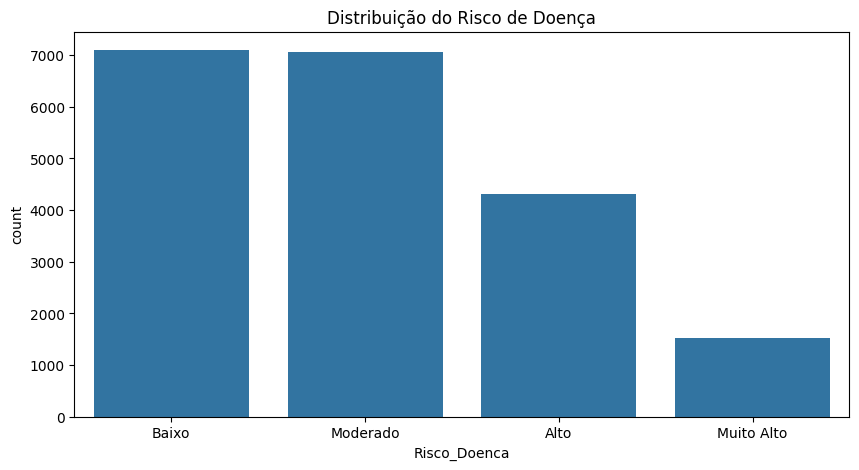

In [6]:
# ============================================
# 3. ANÁLISE EXPLORATÓRIA (EDA)
# ============================================

plt.figure(figsize=(10,5))
sns.countplot(x="Risco_Doenca", data=df)
plt.title("Distribuição do Risco de Doença")
plt.show()


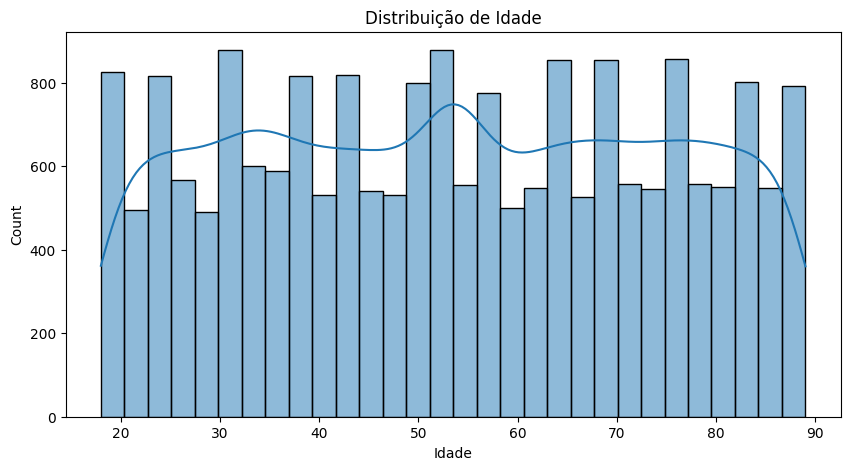

In [7]:
# ============================================
# 3.1
# ============================================

plt.figure(figsize=(10,5))
sns.histplot(df["Idade"], bins=30, kde=True)
plt.title("Distribuição de Idade")
plt.show()

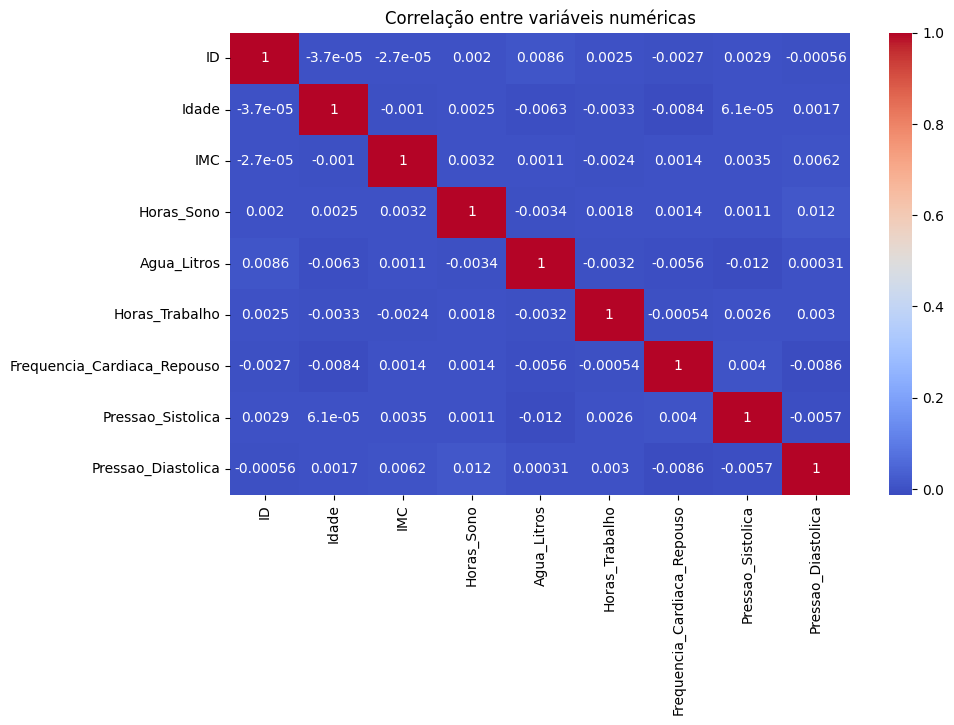

In [8]:
# ============================================
# 3.2
# ============================================

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlação entre variáveis numéricas")
plt.show()

In [9]:
# ============================================
# 4. PRÉ-PROCESSAMENTO DOS DADOS
# ============================================

# Separando X e y
X = df.drop("Risco_Doenca", axis=1)
y = df["Risco_Doenca"]

# Transformando variáveis categóricas
X = pd.get_dummies(X, drop_first=True)

# Transformando variável alvo
le = LabelEncoder()
y = le.fit_transform(y)

# Dividindo treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Normalização
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [10]:
# ============================================
# 5. TREINAMENTO E COMPARAÇÃO DE MODELOS
# ============================================

modelos = {
    "LogisticRegression": LogisticRegression(max_iter=2000),
    "RandomForest": RandomForestClassifier(n_estimators=80, random_state=42),
    "DecisionTree": RandomForestClassifier(n_estimators=1, random_state=42)
}

melhor_modelo = None
melhor_score = 0
nome_melhor_modelo = ""

In [11]:
# ============================================
# 6. REGISTRO COM MLFLOW
# ============================================

mlflow.set_experiment("Projeto_Final_Saude")

for nome, modelo in modelos.items():

    with mlflow.start_run(run_name=nome):

        modelo.fit(X_train, y_train)
        y_pred = modelo.predict(X_test)

        acc = accuracy_score(y_test, y_pred)

        print(f"\nModelo: {nome}")
        print("Accuracy:", acc)
        print(classification_report(y_test, y_pred))

        mlflow.log_metric("accuracy", acc)
        mlflow.sklearn.log_model(modelo, nome)

        if acc > melhor_score:
            melhor_score = acc
            melhor_modelo = modelo
            nome_melhor_modelo = nome

2026/03/25 21:40:50 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/03/25 21:40:50 INFO mlflow.store.db.utils: Updating database tables
2026/03/25 21:40:52 INFO mlflow.tracking.fluent: Experiment with name 'Projeto_Final_Saude' does not exist. Creating a new experiment.
2026/03/25 21:41:47 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/25 21:41:47 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



Modelo: LogisticRegression
Accuracy: 0.419
              precision    recall  f1-score   support

           0       0.33      0.34      0.34       861
           1       0.56      0.55      0.55      1421
           2       0.38      0.40      0.39      1414
           3       0.18      0.14      0.16       304

    accuracy                           0.42      4000
   macro avg       0.36      0.36      0.36      4000
weighted avg       0.42      0.42      0.42      4000



2026/03/25 21:43:43 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/25 21:43:43 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



Modelo: RandomForest
Accuracy: 0.67075
              precision    recall  f1-score   support

           0       0.55      0.37      0.45       861
           1       0.77      0.93      0.85      1421
           2       0.60      0.71      0.65      1414
           3       1.00      0.12      0.22       304

    accuracy                           0.67      4000
   macro avg       0.73      0.53      0.54      4000
weighted avg       0.68      0.67      0.64      4000



2026/03/25 21:43:51 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/25 21:43:51 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



Modelo: DecisionTree
Accuracy: 0.50575
              precision    recall  f1-score   support

           0       0.38      0.35      0.37       861
           1       0.65      0.67      0.66      1421
           2       0.46      0.48      0.47      1414
           3       0.32      0.26      0.29       304

    accuracy                           0.51      4000
   macro avg       0.45      0.44      0.45      4000
weighted avg       0.50      0.51      0.50      4000



In [12]:
# ============================================
# 6.1 TREINAMENTO + COMPARAÇÃO DE MODELOS
# ============================================

import mlflow
import mlflow.sklearn
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

mlflow.set_experiment("Projeto_Final_Saude")

resultados = []

for nome, modelo in modelos.items():

    with mlflow.start_run(run_name=nome):

        # Treinar
        modelo.fit(X_train, y_train)

        # Previsão
        y_pred = modelo.predict(X_test)

        # Métricas
        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, average="weighted")
        rec = recall_score(y_test, y_pred, average="weighted")
        f1 = f1_score(y_test, y_pred, average="weighted")

        # Salvar métricas no MLflow
        mlflow.log_metric("accuracy", acc)
        mlflow.log_metric("precision", prec)
        mlflow.log_metric("recall", rec)
        mlflow.log_metric("f1_score", f1)

        # Salvar modelo
        mlflow.sklearn.log_model(modelo, nome)

        resultados.append([nome, acc, prec, rec, f1])

2026/03/25 21:45:22 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/25 21:45:22 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/03/25 21:47:16 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/25 21:47:16 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_p

In [13]:
# ============================================
# 6.2 COMPARAÇÃO DOS MODELOS
# ============================================

import pandas as pd

df_resultados = pd.DataFrame(resultados,
                             columns=["Modelo", "Accuracy", "Precision", "Recall", "F1"])

df_resultados = df_resultados.sort_values(by="F1", ascending=False)

df_resultados

,Modelo,Accuracy,Precision,Recall,F1
1,RandomForest,0.67075,0.681843,0.67075,0.642184
2,DecisionTree,0.50575,0.500112,0.50575,0.502376
0,LogisticRegression,0.41900,0.417410,0.41900,0.417987


In [14]:
# ============================================
# 6.3 ESCOLHA DO MELHOR MODELO
# ============================================

melhor_modelo_nome = df_resultados.iloc[0]["Modelo"]

print("Melhor modelo:", melhor_modelo_nome)

Melhor modelo: RandomForest


In [15]:
# ============================================
# 6.4 SALVAR O MELHOR MODELO
# ============================================

melhor_modelo = modelos[melhor_modelo_nome]

import joblib
joblib.dump(melhor_modelo, "melhor_modelo.pkl")

print("Modelo salvo com sucesso!")

Modelo salvo com sucesso!


In [16]:
# ============================================
# 6.5 RELATÓRIO FINAL
# ============================================

from sklearn.metrics import classification_report

y_pred = melhor_modelo.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.55      0.37      0.45       861
           1       0.77      0.93      0.85      1421
           2       0.60      0.71      0.65      1414
           3       1.00      0.12      0.22       304

    accuracy                           0.67      4000
   macro avg       0.73      0.53      0.54      4000
weighted avg       0.68      0.67      0.64      4000



In [17]:
# ============================================
# 7. SALVANDO O MELHOR MODELO
# ============================================

joblib.dump(melhor_modelo, "melhor_modelo.pkl")
joblib.dump(scaler, "scaler.pkl")

print("\n===================================")
print("Melhor modelo:", nome_melhor_modelo)
print("Acurácia:", melhor_score)
print("Modelo salvo com sucesso!")
print("===================================")


Melhor modelo: RandomForest
Acurácia: 0.67075
Modelo salvo com sucesso!


In [18]:
# ============================================
# 8. TESTE COM NOVOS DADOS
# ============================================

novo_paciente = X_test[0].reshape(1, -1)
previsao = melhor_modelo.predict(novo_paciente)

print("\nPrevisão do modelo:", le.inverse_transform(previsao))


Previsão do modelo: ['Baixo']
